# Chapter 30 — Noise, Grounding, and EMI
### *Modern Strain Gage Technology* — Companion Notebook

**A strain gage signal is a few millivolts fighting its way through a room full of power lines, motors, and fluorescent ballasts — this notebook maps out the noise floor it has to clear.**

Companion notebook to Chapter 30 — Noise, Grounding, and EMI: Protecting the Signal.

Every measurement system operates in an electromagnetic environment. Thermal noise is generated in every resistor. Power lines radiate 50/60 Hz pickup into every conductor that forms a loop. Variable-frequency drives, servo motors, and radio transmitters inject broadband interference. The strain gage signal — a few millivolts at best — must survive all of this and arrive at the ADC with enough fidelity to be useful.

The two disciplines that control noise at the system level are *grounding* (ensuring that all reference potentials connect at a single point, preventing ground loop currents) and *shielding* (preventing electromagnetic fields from coupling into the signal cables). But even before those measures are applied, the fundamental noise floor set by thermodynamics — *Johnson noise* — defines the minimum achievable uncertainty. This notebook begins there and builds up to the practical signal-to-noise limit of a real system.

**This notebook demonstrates:**
1. Johnson-Nyquist thermal noise voltage vs. resistance and bandwidth — the irreducible noise floor
2. Signal-to-noise ratio vs. applied strain for a 350 Ω system — showing minimum measurable strain, and why the chapter's "noise as a ratio" argument works

In [1]:
# !pip install numpy matplotlib

from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11, 'axes.titlesize': 12})

# Boltzmann constant (J/K), reused throughout for Johnson-Nyquist noise.
K_B = 1.38e-23

# All saved figures land here. The book includes these exact files — do not rename them.
OUT_DIR = Path("../src/media/ch30")
OUT_DIR.mkdir(parents=True, exist_ok=True)

---
## 1 — Johnson Noise: The Irreducible Floor

Johnson-Nyquist noise arises from the thermal agitation of charge carriers in any resistor at temperature T. Its RMS voltage is V_n = √(4k_B·T·R·Δf), where Δf is the measurement bandwidth. The key dependencies: noise grows as √R (so higher-resistance gages have more thermal noise), and as √BW (so narrowing the bandwidth is the primary way to reduce noise). Temperature reduction helps too — cooling from 300 K to 77 K (liquid nitrogen) reduces Johnson noise by a factor of √(300/77) ≈ 2, though this is rarely practical in structural testing.

The table shows that for a 350 Ω gage at 1 kHz bandwidth, the Johnson noise is about 76 nV RMS — well below the amplifier noise (typically 100–500 nV) and far below the ambient interference in most test environments. Johnson noise is therefore not usually the limiting factor in practical strain gage measurements; EMI and grounding problems are. But it sets the absolute lower bound that no amount of engineering can overcome.

In [2]:
def johnson_noise_rms(R, BW, T=300.0):
    """RMS Johnson-Nyquist thermal noise voltage of a resistor.

    Parameters
    ----------
    R : float
        Resistance, ohms.
    BW : float
        Measurement (noise) bandwidth, Hz.
    T : float
        Absolute temperature, K (default 300 K, room temperature).

    Returns
    -------
    float
        RMS noise voltage in volts, Vn = sqrt(4 * K_B * T * R * BW).
    """
    return np.sqrt(4 * K_B * T * R * BW)


# Common gage/bridge resistances and a span of measurement bandwidths.
RESISTANCES_OHM = [120, 350, 1000]
BANDWIDTHS_HZ = [100, 1000, 10000]

print("Johnson-Nyquist noise: Vn = sqrt(4*K_B*T*R*BW)   (T = 300 K)")
print(f"{'R (Ω)':>8}  {'BW (Hz)':>10}  {'Vn RMS (nV)':>14}")
for R in RESISTANCES_OHM:
    for BW in BANDWIDTHS_HZ:
        Vn_nV = johnson_noise_rms(R, BW) * 1e9
        print(f"{R:>8}  {BW:>10,}  {Vn_nV:>14.2f}")
    print()

Johnson-Nyquist noise: Vn = sqrt(4*K_B*T*R*BW)   (T = 300 K)
   R (Ω)     BW (Hz)     Vn RMS (nV)
     120         100           14.10
     120       1,000           44.58
     120      10,000          140.97

     350         100           24.07
     350       1,000           76.13
     350      10,000          240.75

    1000         100           40.69
    1000       1,000          128.69
    1000      10,000          406.94



---
## 2 — SNR vs. Applied Strain: Intrinsic Floor and Real Interference

The signal-to-noise ratio grows linearly with strain on a log-log plot (20 dB per decade), because the bridge output voltage grows linearly with strain while the noise floor is fixed. The SNR = 0 dB crossing — where signal and noise are equal — gives the minimum measurable strain under those conditions.

Two floors are plotted. The **intrinsic floor** is the 76 nV Johnson noise from Section 1 combined in quadrature with 5 nV/√Hz amplifier noise over 1 kHz: about 0.18 µV RMS, or roughly 0.07 µε at 5 V. That floor is a best case; a real laboratory usually adds far more coupled interference. The **interference floor** is an assumed, illustrative 5 µV RMS of externally coupled pickup, and it does not change with excitation.

Against that interference floor the excitation voltage becomes the lever the chapter's *noise as a ratio* section describes. The bridge output scales with excitation — `Vsig = Vex · GF · ε / 4` — while externally coupled noise does not, so each doubling of excitation lifts the SNR curve by 6 dB. At 5 V the 60 dB line is crossed near 1,900 µε; at 10 V near 970 µε; at 2 V not until about 4,800 µε. The gain is bounded by gage self-heating (power per arm is `Vex**2 / (4 * R)`, about 71 mW at 10 V on 350 Ω), so the top curve is only usable on a gage and substrate that can shed that heat.

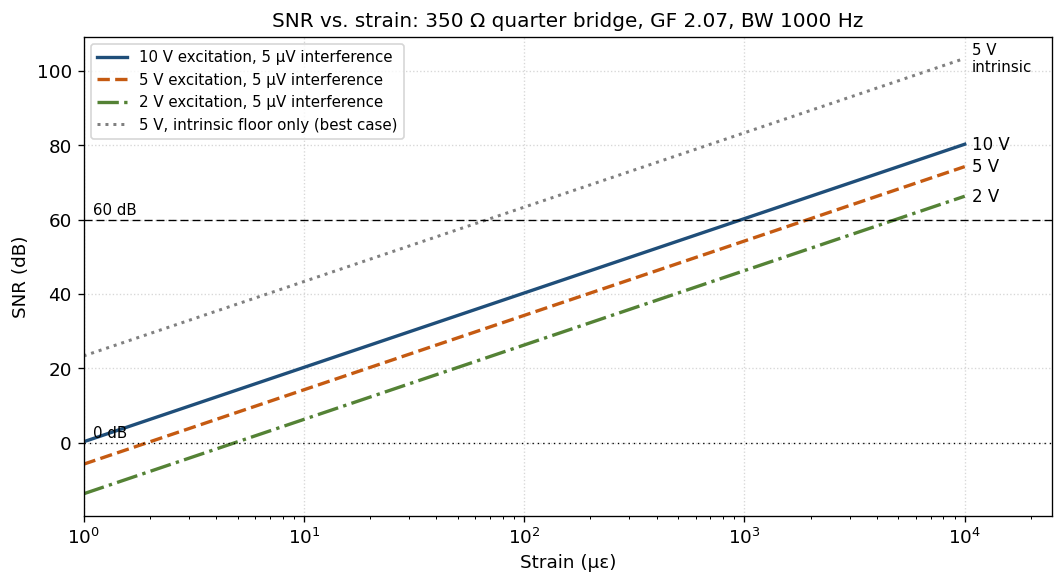

Intrinsic floor 175 nV RMS; with interference 5.003 µV RMS
  10 V: 0 dB at   0.97 µε, 60 dB at     967 µε,  71.4 mW per arm
   5 V: 0 dB at   1.93 µε, 60 dB at    1934 µε,  17.9 mW per arm
   2 V: 0 dB at   4.83 µε, 60 dB at    4834 µε,   2.9 mW per arm
   5 V, intrinsic only: 60 dB at 68 µε


In [3]:
# Representative quarter-bridge system parameters.
R_GAGE_OHM = 350.0        # gage / bridge-arm resistance, Ω
GAGE_FACTOR = 2.07        # constantan gage factor (dimensionless)
BANDWIDTH_HZ = 1000       # measurement bandwidth, Hz
TEMPERATURE_K = 300.0     # absolute temperature, K
AMP_NOISE_DENSITY = 5e-9  # amplifier input-referred noise density, V/sqrt(Hz)
V_INTERFERENCE = 5e-6     # assumed (illustrative) externally coupled pickup, V RMS
EXCITATIONS_V = [10.0, 5.0, 2.0]   # excitation voltages compared, V

# Sweep applied strain from 1 to 10,000 με on a log axis (1e-6 = 1 με).
strain = np.logspace(0, 4, 300) * 1e-6

# Intrinsic floor: Johnson (resistor) noise and amplifier noise add in quadrature.
V_johnson_sq = johnson_noise_rms(R_GAGE_OHM, BANDWIDTH_HZ, TEMPERATURE_K) ** 2
V_amp_sq = AMP_NOISE_DENSITY ** 2 * BANDWIDTH_HZ
V_intrinsic = np.sqrt(V_johnson_sq + V_amp_sq)
# Realistic floor: interference dominates; the intrinsic terms still add in quadrature.
V_real = np.sqrt(V_intrinsic**2 + V_INTERFERENCE**2)


def snr_db(v_ex, v_noise):
    """SNR (dB) of a quarter-bridge output, Vsig = Vex*GF*eps/4, against a fixed noise floor."""
    return 20 * np.log10(v_ex * GAGE_FACTOR * strain / 4 / v_noise)


# Line style carries identity as well as colour (the softcover prints in grayscale).
styles = {10.0: ('#1f4e79', '-'), 5.0: ('#c55a11', '--'), 2.0: ('#548235', '-.')}

fig, ax = plt.subplots(figsize=(9, 5))
x = strain * 1e6
for v_ex in EXCITATIONS_V:
    col, ls = styles[v_ex]
    y = snr_db(v_ex, V_real)
    ax.semilogx(x, y, color=col, ls=ls, lw=2, label=f'{v_ex:.0f} V excitation, 5 µV interference')
    ax.text(x[-1] * 1.08, y[-1], f'{v_ex:.0f} V', color='black', va='center', fontsize=10)
y_int = snr_db(5.0, V_intrinsic)
ax.semilogx(x, y_int, color='gray', ls=':', lw=1.8, label='5 V, intrinsic floor only (best case)')
ax.text(x[-1] * 1.08, y_int[-1], '5 V\nintrinsic', color='black', va='center', fontsize=9)
ax.axhline(0, color='black', lw=0.8, ls=(0, (1, 3)))
ax.axhline(60, color='black', lw=0.8, ls=(0, (6, 3)))
ax.text(1.1, 1.5, '0 dB', fontsize=9)
ax.text(1.1, 61.5, '60 dB', fontsize=9)
ax.set_xlim(1, 10000 * 2.5)
ax.set_xlabel('Strain (µε)')
ax.set_ylabel('SNR (dB)')
ax.set_title(f'SNR vs. strain: {R_GAGE_OHM:.0f} Ω quarter bridge, GF {GAGE_FACTOR}, BW {BANDWIDTH_HZ} Hz')
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.savefig(OUT_DIR / 'fig30_nb1_snr_vs_strain.png', bbox_inches='tight', dpi=300)
plt.show()

print(f"Intrinsic floor {V_intrinsic*1e9:.0f} nV RMS; with interference {V_real*1e6:.3f} µV RMS")
for v_ex in EXCITATIONS_V:
    sens = v_ex * GAGE_FACTOR / 4            # V per unit strain
    e0 = V_real / sens * 1e6
    e60 = 1000 * V_real / sens * 1e6
    p_arm = v_ex**2 / (4 * R_GAGE_OHM) * 1e3
    print(f"{v_ex:>4.0f} V: 0 dB at {e0:6.2f} µε, 60 dB at {e60:7.0f} µε, {p_arm:5.1f} mW per arm")
print(f"   5 V, intrinsic only: 60 dB at {1000*V_intrinsic/(5*GAGE_FACTOR/4)*1e6:.0f} µε")


---
## Where to take this next

This notebook is a starting point. A few concrete extensions turn it into a working noise budget for a real installation:

1. **Add the excitation-voltage lever explicitly.** Sweep `V_EXCITATION` (say 2, 5, 10 V) and overlay the resulting SNR curves, then add the gage self-heating limit — power per bridge arm is `P = V_EXCITATION**2 / (4 * R_GAGE_OHM)` — and mark where raising excitation stops being safe. This makes the chapter's "noise as a ratio" caveat quantitative: the free SNR runs out when the grid gets too hot.

2. **Build a realistic noise model.** Extend `johnson_noise_rms` into a full input-referred budget: add the amplifier's `1/f` (flicker) corner and its current-noise term flowing through the source resistance, then plot minimum measurable strain vs. bandwidth. You will see why narrowing the bandwidth — the chapter's cheapest lever — pays off, and where it stops helping once flicker noise dominates at low frequency.

3. **Simulate 60 Hz pickup and recover the signal.** Generate a synthetic strain history with `np.random.default_rng(seed)`, add a coupled 60 Hz interference tone (the fluorescent-ballast story that opens the chapter), then compare a notch filter against synchronous averaging for recovering the true strain. This connects the frequency-domain view of interference to the physical countermeasures — shielding, twisting, and grounding — described in the chapter.